# WP9 — p-value provenance: panels re-created with correct statistics labels

Reviewer minor comment 3: *"…clearly indicate in axis labels or legends whether p-values
are raw or FDR-adjusted… In Figure 1D, for example, the third vertical bar plot labeled
'-log10(p-value)' should read '-log10(FDR-corrected p-value)'."*

**Nothing here changes a number.** Every panel reads the same unchanged CSV the frozen
notebook read and plots the same column; only labels, legends and colourbar titles differ.
The panels are re-created here because `TEs_mapped_on_TSS_analysis.ipynb` is frozen for
this revision (plan §2, §7.2) — the plotting code is **copied** from it, cell by cell, and
each section below names its source cell.

It is also journal policy, not only a reviewer preference: G3's statistics guidance
requires that it be clear whether p-values are raw or corrected, that the correction be
named, and that raw p-values be available in the supporting materials
(`G3_article_guidelines.md` §5).

| Panel | Source cell | Statistic | What was wrong |
|---|---|---|---|
| 1D | `TEs…ipynb` 63 | Fisher exact, BH-adjusted | axis said `-log10(p)`; the column plotted is `Enrichment_p_value_adjusted` |
| 1D bars 1–2 | 63 | empirical permutation p, BH-adjusted | the `ns` marks were unexplained |
| 2D–2F | 105 | Mann–Whitney U, BH across 15 pairs | colourbar said `adj. p` without naming BH/FDR |
| 3A/3B | 174, 175 | two-sample Kolmogorov–Smirnov | raw, and not stated to be raw |
| S1 | 172 | Kolmogorov–Smirnov per class | raw, and not stated to be raw |
| S2 | 181 | Mann–Whitney U, BH across 44 families | stars carried no legend at all — the plan expected "already stated"; it is not |
| S3 | 194 | Mann–Whitney U, BH across 44 families | same |

Also applies **G11**: every baked-in `fig.suptitle(...)` is removed, because G3 wants panel
titles in the caption, not rendered into the artwork.

In [1]:
import io
import itertools
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import kstest
from statsmodels.stats.multitest import multipletests

sys.path.insert(0, os.path.abspath("."))
import revision_lib as rl

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({"font.size": rl.GLOBAL_FONT_SIZE})
os.makedirs(rl.SVG_DIR, exist_ok=True)

SVG = rl.SVG_DIR
OUT = rl.OUTPUT_DIR
REPO = rl.REPO_DIR

# Copied from the frozen notebook cell 3 so the colours are identical.
class_names = rl.CLASS_NAMES
class_names_p = rl.CLASS_PALETTE

## 1. Inputs — the same files, unchanged

`enrichment_families_with_random.csv` and `enrichment_subfamilies_with_random.csv` stand as
published (decision D1 keeps N = 500, so no enrichment table is regenerated).

In [2]:
enrichment_df_families = pd.read_csv(os.path.join(REPO, "enrichment_families_with_random.csv"))
# Figures 2D-2F are family-level (see cell below), and the families table stores
# no Status column — it is derived, exactly as nb06 cell 26 derives it.
enrichment_df_families["Status"] = np.where(
    enrichment_df_families["p_adjusted_empirical_bh"] < 0.05,
    "Significant", "Non-Significant",
)

# Copied from frozen cell 79: Status and the fold-change column are derived, not stored.
enrichment_df_subfamilies = pd.read_csv(
    os.path.join(REPO, "enrichment_subfamilies_with_random.csv"), index_col=0
).reset_index()
enrichment_df_subfamilies["Status"] = np.where(
    enrichment_df_subfamilies["p_adjusted_empirical_bh"] < 0.05,
    "Significant", "Non-Significant",
)
enrichment_df_subfamilies["OR_Observed_to_Random"] = (
    enrichment_df_subfamilies["Observed_Odds_Ratio"]
    / enrichment_df_subfamilies["Random_Odds_Ratio_Mean"]
)
print(f"families {enrichment_df_families.shape}, "
      f"subfamilies {enrichment_df_subfamilies.shape}")
print(f"significant families (empirical BH < 0.05): "
      f"{int((enrichment_df_families.Status == 'Significant').sum())} of "
      f"{len(enrichment_df_families)}")
print(f"significant subfamilies (empirical BH < 0.05): "
      f"{int((enrichment_df_subfamilies.Status == 'Significant').sum())}")

families (44, 22), subfamilies (1143, 20)
significant families (empirical BH < 0.05): 22 of 44
significant subfamilies (empirical BH < 0.05): 507


## 2. Figure 1D — the panel the reviewer named

Copied from frozen cell 63. Five sub-panels sharing the family axis. Four label changes and
one removal:

1. `ax_p` title `"Significance\n-log10(adj p)"` → `"Significance\n-log10(FDR-corrected p)"`
2. `ax_p` x-label `"-log10(p)"` → `"-log10(FDR-corrected Fisher exact p-value)"`
3. `ax_or` title gains the source of its `ns` marks (FDR-corrected empirical p)
4. the shared legend gains an explicit `ns` entry
5. `fig.suptitle("Detailed TE Family Enrichment Analysis")` deleted (G11)

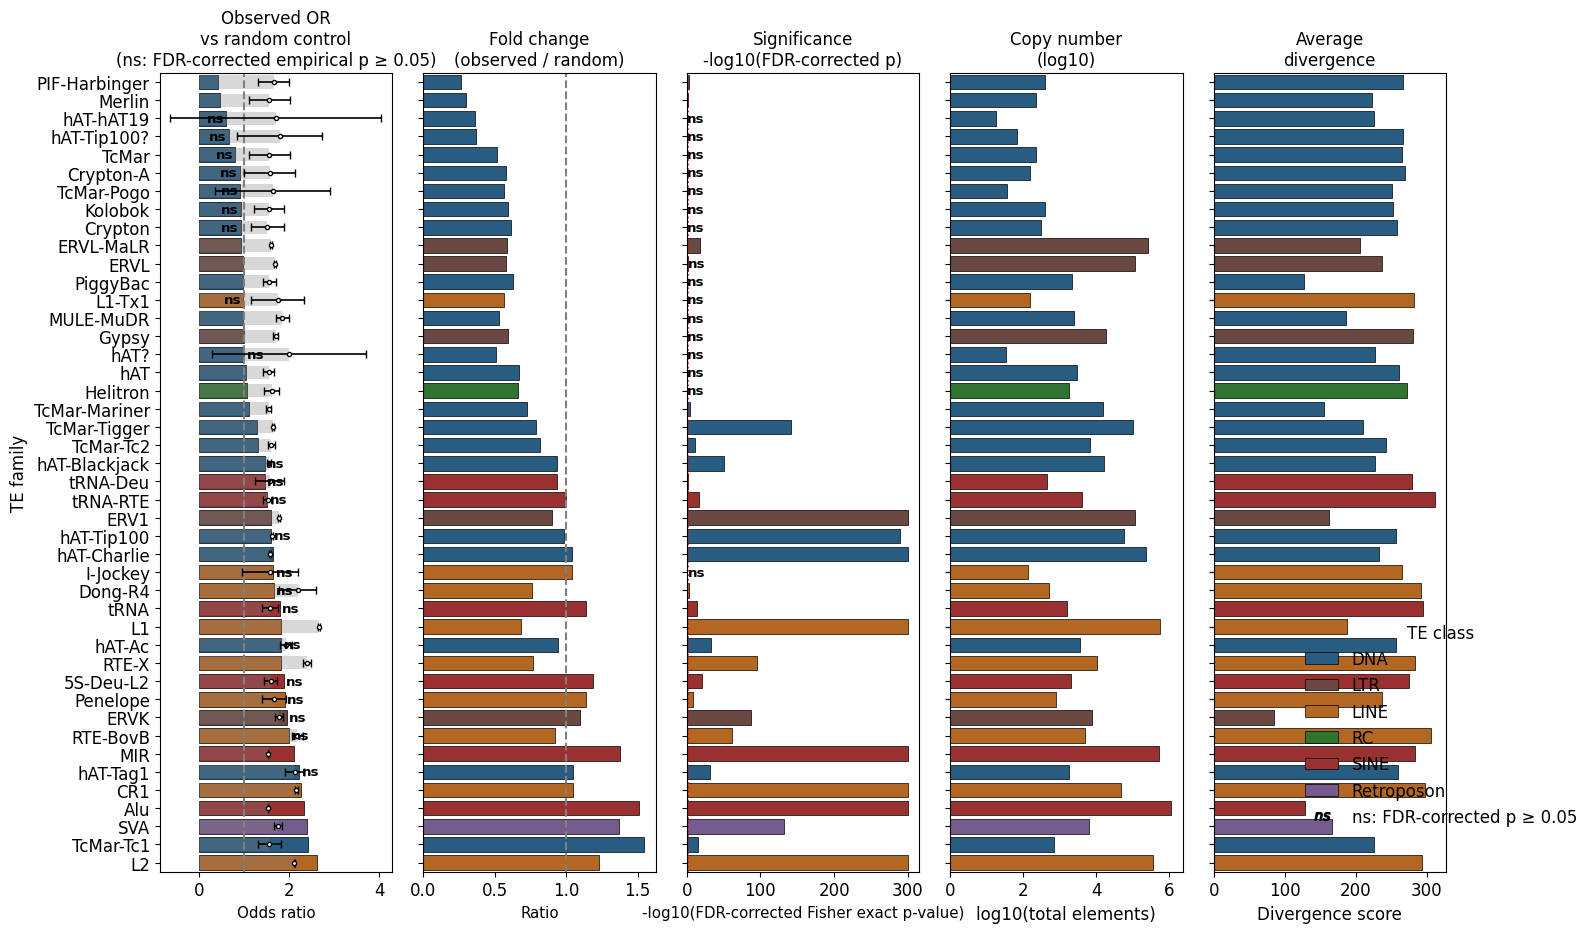

In [3]:
data_to_plot = enrichment_df_families.sort_values(
    "Observed_Odds_Ratio", ascending=True
).reset_index(drop=True)

EPSILON = 1e-300
data_to_plot["neg_log10_adj_p"] = -np.log10(
    data_to_plot["Enrichment_p_value_adjusted"] + EPSILON
)
plot_order = data_to_plot["family_name"].tolist()

fig, (ax_or, ax_fold_change, ax_p, ax_count_all, ax_div_all) = plt.subplots(
    1, 5, figsize=(16, 10), sharey=True
)

sns.barplot(data=data_to_plot, y="family_name", x="Observed_Odds_Ratio", hue="class_name",
            order=plot_order, palette=class_names_p, ax=ax_or, dodge=False,
            linewidth=0.5, edgecolor="black")

bar_height = 0.8
for i, row in data_to_plot.iterrows():
    y_pos = i
    obs_or = row["Observed_Odds_Ratio"]
    mean_or = row["Random_Odds_Ratio_Mean"]
    sd_or = row["Random_Odds_Ratio_SD"]
    p_adj = row["p_adjusted_empirical_bh"]

    if pd.notna(mean_or):
        ax_or.barh(y=y_pos, width=mean_or, height=bar_height * 0.9, color="gray",
                   alpha=0.3, zorder=2)
        if pd.notna(sd_or) and sd_or > 0:
            ax_or.errorbar(x=mean_or, y=y_pos, xerr=sd_or, fmt="o", capsize=3,
                           color="black", elinewidth=1.2, markersize=3,
                           markerfacecolor="white", markeredgecolor="black", zorder=3)
    if p_adj >= 0.05:
        x_text, ha = (obs_or + 0.05, "left") if obs_or >= 1 else (obs_or - 0.05, "right")
        ax_or.text(x_text, y_pos, "ns", ha=ha, va="center", fontsize=rl.fs(8), color="black",
                   weight="bold", zorder=4)

ax_or.axvline(1, color="gray", linestyle="--", linewidth=1.5)
# LABEL FIX 3: name the test behind the ns marks.
ax_or.set_title("Observed OR\nvs random control\n(ns: FDR-corrected empirical p ≥ 0.05)",
                fontsize=rl.fs(10))
ax_or.set_xlabel("Odds ratio", fontsize=rl.fs(9))
ax_or.set_ylabel("TE family", fontsize=rl.fs(10))
ax_or.get_legend().remove()

sns.barplot(data=data_to_plot, y="family_name", x="OR_Observed_to_Random", hue="class_name",
            order=plot_order, palette=class_names_p, ax=ax_fold_change, dodge=False,
            linewidth=0.5, edgecolor="black")
ax_fold_change.axvline(1, color="gray", linestyle="--", linewidth=1.5)
ax_fold_change.set_title("Fold change\n(observed / random)", fontsize=rl.fs(10))
ax_fold_change.set_xlabel("Ratio", fontsize=rl.fs(9))
ax_fold_change.get_legend().remove()

sns.barplot(data=data_to_plot, y="family_name", x="neg_log10_adj_p", hue="class_name",
            order=plot_order, palette=class_names_p, ax=ax_p, dodge=False,
            linewidth=0.5, edgecolor="black")
ax_p.axvline(-np.log10(0.05), color="red", linestyle=":", linewidth=1.2)
# LABEL FIXES 1 and 2 — the two strings the reviewer quoted.
ax_p.set_title("Significance\n-log10(FDR-corrected p)", fontsize=rl.fs(10))
ax_p.set_xlabel("-log10(FDR-corrected Fisher exact p-value)", fontsize=rl.fs(9))
ax_p.get_legend().remove()

for i, row in data_to_plot.iterrows():
    if row["Enrichment_p_value_adjusted"] >= 0.05:
        ax_p.text(row["neg_log10_adj_p"] + 0.1, i, "ns", ha="left", va="center",
                  fontsize=rl.fs(8), color="black", weight="bold")

sns.barplot(data=data_to_plot, y="family_name", x="Total_TEs_number_log", hue="class_name",
            order=plot_order, palette=class_names_p, ax=ax_count_all, dodge=False,
            linewidth=0.5, edgecolor="black")
ax_count_all.set_title("Copy number\n(log10)", fontsize=rl.fs(10))
ax_count_all.set_xlabel("log10(total elements)", fontsize=rl.fs(10))
ax_count_all.get_legend().remove()

sns.barplot(data=data_to_plot, y="family_name", x="Average_divergence_all",
            hue="class_name", order=plot_order, palette=class_names_p, ax=ax_div_all,
            dodge=False, linewidth=0.5, edgecolor="black")
ax_div_all.set_title("Average\ndivergence", fontsize=rl.fs(10))
ax_div_all.set_xlabel("Divergence score", fontsize=rl.fs(10))
ax_div_all.get_legend().remove()

handles, labels = ax_div_all.get_legend_handles_labels()
# LABEL FIX 4: the ns convention is stated in the legend, not left to the caption.
handles = handles + [Line2D([], [], ls="", marker="$ns$", color="black", markersize=rl.fs(9))]
labels = labels + ["ns: FDR-corrected p ≥ 0.05"]
fig.legend(handles, labels, title="TE class", loc="lower right",
           bbox_to_anchor=(1.0, 0.1), frameon=False, fontsize=rl.fs(10))

# G11: no fig.suptitle here — the frozen cell had one.
plt.tight_layout(rect=[0, 0, 0.92, 0.95])
fig.savefig(os.path.join(SVG, "Fig1D_relabelled.svg"), format="svg",
            bbox_inches="tight", transparent=True)
plt.show()

## 3. Figures 2D–2F — boxplot with a pairwise significance matrix

Copied from frozen cell 105. Three panels, one per plotted quantity. Statistic:
Mann–Whitney U on every one of the 15 class pairs, Benjamini–Hochberg corrected across
those 15 tests.

**Two corrections, made 2026-08-05 against the published caption.** The first version of
this notebook plotted the *subfamily* table (n = 1,129, one point per subfamily) and
assigned the panel letters in the order the quantities happen to appear in the enrichment
table. Both disagree with the published Figure 2 legend, which reads *"Box plot of
**observed to random OR** by TE **families** between TE classes"* for (D), observed OR for
(E) and random OR for (F):

| Panel | Published caption | What is plotted now |
|---|---|---|
| 2D | observed to random OR, by families | `OR_Observed_to_Random` on 44 families |
| 2E | observed OR, by families | `Observed_Odds_Ratio` on 44 families |
| 2F | random OR, by families | `Random_Odds_Ratio_Mean` on 44 families |

So the level moves from subfamily to family and D/E swap. **No manuscript text changes**:
at family level the three panels reproduce the published Results sentences exactly, and
cell 17 asserts that rather than trusting it. This is the third panel-identity defect of
the same class (after Figure 7 and Supplementary 8B), which is why the check is an
assertion and not a habit.

Family counts per class are DNA 22, LINE 9, SINE 6, LTR 5, Retroposon 1, RC 1. Retroposon
and RC have a single family each, so they have no distribution: they are drawn as single
points without a box, and the 9 class pairs involving them are annotated `n/a` rather than
`ns`. None of the published claims depends on those pairs.

Label changes: the colourbar and the star legend name the test and the correction, and the
`n` per class is printed on the axis so the reader can see what the boxes summarise.

/tmp/ipykernel_1139/1388836632.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=frame[frame[x_name].isin(boxable)], x=x_name, y=y_name, ax=ax_box,


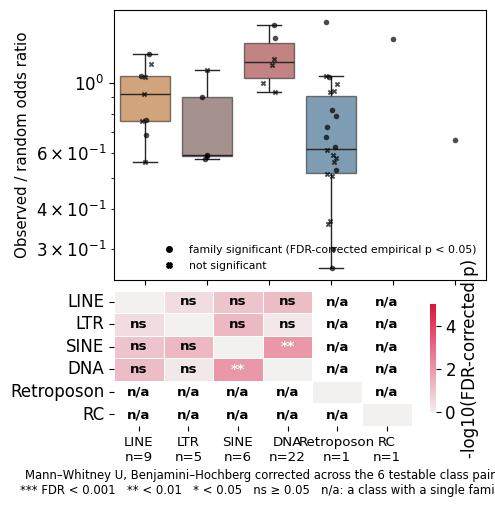

Fig2D: OR_Observed_to_Random on 44 families -> Fig2D_relabelled.svg; significant pairs: [('DNA', 'SINE')]


/tmp/ipykernel_1139/1388836632.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=frame[frame[x_name].isin(boxable)], x=x_name, y=y_name, ax=ax_box,


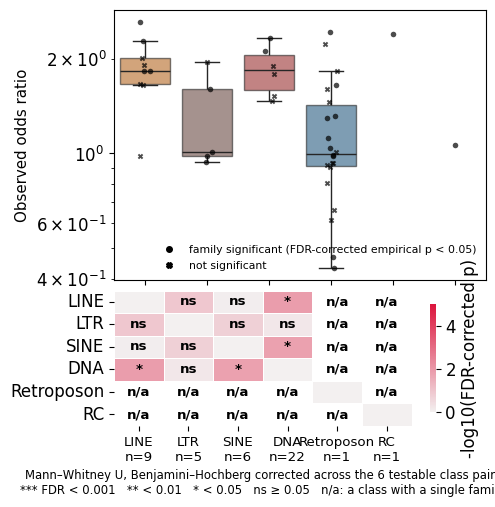

Fig2E: Observed_Odds_Ratio on 44 families -> Fig2E_relabelled.svg; significant pairs: [('DNA', 'LINE'), ('DNA', 'SINE')]


/tmp/ipykernel_1139/1388836632.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=frame[frame[x_name].isin(boxable)], x=x_name, y=y_name, ax=ax_box,


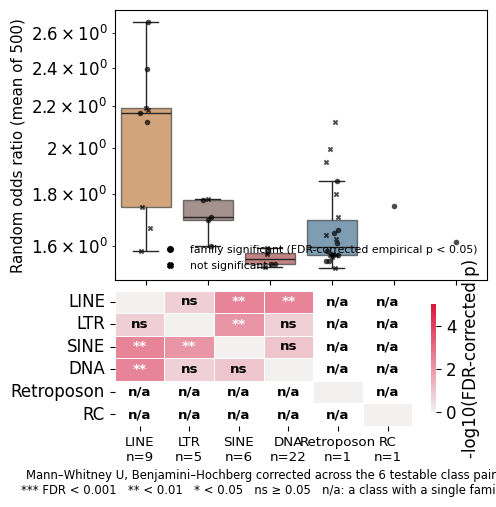

Fig2F: Random_Odds_Ratio_Mean on 44 families -> Fig2F_relabelled.svg; significant pairs: [('DNA', 'LINE'), ('LINE', 'SINE'), ('LTR', 'SINE')]

families per class:
class_name
DNA           22
LINE           9
SINE           6
LTR            5
RC             1
Retroposon     1


In [4]:
# Classes with only one family have no distribution to box. Drawing a box around a
# single point would imply a spread that does not exist.
MIN_GROUP_FOR_BOX = 2


def boxplot_with_significance_matrix(y_name, panel_name, y_label, log_y=True):
    """One Figure-2 panel: FAMILY distributions per class + BH-corrected pair matrix.

    The published caption and Results text are family-level ("Box plot of ... by TE
    families between TE classes"), and the letters are D = obs/random OR, E = observed
    OR, F = random OR. The first version of this notebook used the subfamily table and
    the D/E order swapped; both are corrected here. The assertions in cell 17 check the
    panels against the published sentences.

    Returns the adjusted p-value matrix and the set of pairs significant at FDR 0.05.
    """
    x_name = "class_name"
    frame = enrichment_df_families[enrichment_df_families[y_name] > 0].copy()
    frame = frame.replace([np.inf, -np.inf], np.nan).dropna(subset=[x_name, y_name])

    counts = frame[x_name].value_counts().reindex(class_names).fillna(0).astype(int)

    box_pairs = list(itertools.combinations(class_names, 2))
    pair_results, testable = [], []
    for g1, g2 in box_pairs:
        d1 = frame.loc[frame[x_name] == g1, y_name]
        d2 = frame.loc[frame[x_name] == g2, y_name]
        # A Mann-Whitney U against a single observation is not a test; those pairs are
        # reported as n/a instead of being given a p-value the data cannot support.
        if min(len(d1), len(d2)) < MIN_GROUP_FOR_BOX:
            continue
        _, p = stats.mannwhitneyu(d1, d2)
        pair_results.append({"g1": g1, "g2": g2, "p_raw": p})
        testable.append((g1, g2))

    _, adj_p_values, _, _ = multipletests([r["p_raw"] for r in pair_results],
                                          method="fdr_bh")
    # Built as a numpy array first: under pandas 3 a DataFrame's `.values` is read-only,
    # so the frozen cell's np.fill_diagonal(df.values, ...) no longer works in place.
    # NaN marks an untestable pair, which the annotation loop renders as n/a.
    position = {name: i for i, name in enumerate(class_names)}
    p_array = np.full((len(class_names), len(class_names)), np.nan, dtype=float)
    np.fill_diagonal(p_array, 1.0)
    for i, res in enumerate(pair_results):
        a, b = position[res["g1"]], position[res["g2"]]
        p_array[a, b] = p_array[b, a] = adj_p_values[i]
    p_matrix_adj = pd.DataFrame(p_array, index=class_names, columns=class_names)
    neg_log_p = -np.log10(p_matrix_adj + 1e-300)

    significant = {
        tuple(sorted((res["g1"], res["g2"])))
        for res, p_adj in zip(pair_results, adj_p_values) if p_adj < 0.05
    }

    fig = plt.figure(figsize=(4.8, 5.4))
    gs = GridSpec(2, 1, height_ratios=[2, 1], hspace=0.05)
    ax_box, ax_heat = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    # Boxes only for the classes that have a distribution; the singleton classes still
    # get their point from the stripplot below, at their own x position.
    boxable = [c for c in class_names if counts[c] >= MIN_GROUP_FOR_BOX]
    sns.boxplot(data=frame[frame[x_name].isin(boxable)], x=x_name, y=y_name, ax=ax_box,
                order=class_names, palette=class_names_p, boxprops={"alpha": 0.6},
                showfliers=False)
    for status, marker in [("Significant", "o"), ("Non-Significant", "X")]:
        subset = frame[frame["Status"] == status] if status == "Significant" \
            else frame[frame["Status"] != "Significant"]
        sns.stripplot(data=subset, x=x_name, y=y_name, ax=ax_box, order=class_names,
                      color="black", marker=marker, size=4, alpha=0.7, jitter=True,
                      zorder=3)
    if log_y:
        ax_box.set_yscale("log")
    ax_box.set_xlabel("")
    ax_box.set_ylabel(y_label, fontsize=rl.fs(9))
    ax_box.tick_params(labelbottom=False)
    # Point marker meaning is a per-family FDR call, so say which one.
    ax_box.legend(
        handles=[
            Line2D([], [], ls="", marker="o", color="black", markersize=4,
                   label="family significant (FDR-corrected empirical p < 0.05)"),
            Line2D([], [], ls="", marker="X", color="black", markersize=4,
                   label="not significant"),
        ],
        frameon=False, fontsize=rl.fs(6.5), loc="lower right",
    )

    sns.heatmap(
        neg_log_p, ax=ax_heat, cmap=sns.light_palette("crimson", as_cmap=True),
        cbar=True, annot=False, square=False, linewidths=0.5, linecolor="white",
        vmin=0, vmax=5,
        # LABEL FIX: name the correction, not just "adj."
        cbar_kws={"label": "-log10(FDR-corrected p)", "shrink": 0.8},
    )
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            p_adj = p_matrix_adj.iloc[i, j]
            if i == j:
                text = ""
            elif pd.isna(p_adj):
                text = "n/a"
            elif p_adj < 0.001:
                text = "***"
            elif p_adj < 0.01:
                text = "**"
            elif p_adj < 0.05:
                text = "*"
            else:
                text = "ns"
            ax_heat.text(j + 0.5, i + 0.5, text, ha="center", va="center",
                         fontsize=rl.fs(8), weight="bold",
                         color="white" if pd.notna(p_adj) and p_adj < 0.01 else "black")
    ax_heat.set_xticklabels(
        [f"{c}\nn={counts[c]}" for c in class_names], fontsize=rl.fs(8), rotation=0
    )
    ax_heat.set_xlabel(
        f"Mann–Whitney U, Benjamini–Hochberg corrected across the {len(pair_results)} "
        f"testable class pairs\n"
        "*** FDR < 0.001   ** < 0.01   * < 0.05   ns ≥ 0.05   "
        "n/a: a class with a single family",
        fontsize=rl.fs(7),
    )
    ax_heat.set_ylabel("")

    path = os.path.join(SVG, f"{panel_name}_relabelled.svg")
    fig.savefig(path, format="svg", bbox_inches="tight", transparent=True)
    plt.show()
    print(f"{panel_name}: {y_name} on {len(frame)} families -> "
          f"{os.path.basename(path)}; significant pairs: "
          f"{sorted(significant) if significant else 'none'}")
    return p_matrix_adj, significant


matrices, significant_pairs = {}, {}
# Panel letters follow the published caption, not the order the quantities happen to
# appear in the enrichment table.
for panel_name, y_name, y_label, log_y in [
    ("Fig2D", "OR_Observed_to_Random", "Observed / random odds ratio", True),
    ("Fig2E", "Observed_Odds_Ratio", "Observed odds ratio", True),
    ("Fig2F", "Random_Odds_Ratio_Mean", "Random odds ratio (mean of 500)", True),
]:
    matrices[panel_name], significant_pairs[panel_name] = \
        boxplot_with_significance_matrix(y_name, panel_name, y_label, log_y)

print("\nfamilies per class:")
print(enrichment_df_families["class_name"].value_counts().to_string())

## 4. Divergence distributions — the data for Figures 3A/3B, S1, S2, S3

`repeat_masker` is the canonical §3.0 BED. `repeat_masker_genes` is the same elements
restricted to the 10 kb TSS windows; the frozen notebook read it from
`epigenomic_files/BE2C.H3K9me3.chm13v2.0.repeats_intersected_with_TSS.bed`, which is the
same intersection `05a_build_windows.sh` reproduces (582,540 hits, identical class counts).
Element **length** is needed for S3, so the intersection is regenerated here with
coordinates and cached.

In [5]:
repeat_masker = pd.read_csv(
    os.path.join(REPO, "T2T_repeat_masker_processed_sorted.bed"), sep="\t", header=None,
    names=["chrom", "chromStart", "chromEnd", "score", "subfamily_name", "family_name",
           "class_name"],
)
repeat_masker["length"] = repeat_masker["chromEnd"] - repeat_masker["chromStart"]
print(f"repeat_masker: {len(repeat_masker):,} elements")

coords_cache = os.path.join(OUT, "observed_TEs_with_coords_10kb.tsv.zst")
if not os.path.exists(coords_cache):
    windows = os.path.join(OUT, "windows_10kb.bed")
    # `-wa -wb` and NOT `-u`: the published set has one row per (element, window) overlap,
    # so an element in two TSS windows is counted twice. That is the multiple-TSS bias the
    # manuscript already flags, and reproducing it is what makes these panels the published
    # ones rather than new ones. Using -u would give 413,282 rows instead of 582,540.
    command = (
        f"bedtools intersect -a {rl.REPEATS_BED} -b {windows} -wa -wb "
        f"| cut -f1-7 | zstd -q -19 -o {coords_cache} -f"
    )
    subprocess.run(command, shell=True, check=True,
                   env=dict(os.environ, LC_ALL="C"))
    print(f"built {os.path.basename(coords_cache)}")

raw = subprocess.run(["zstd", "-dc", coords_cache], capture_output=True,
                     check=True).stdout
repeat_masker_genes = pd.read_csv(
    io.BytesIO(raw), sep="\t", header=None,
    names=["chrom", "chromStart", "chromEnd", "score", "subfamily_name", "family_name",
           "class_name"],
)
repeat_masker_genes["length"] = (
    repeat_masker_genes["chromEnd"] - repeat_masker_genes["chromStart"]
)
print(f"repeat_masker_genes: {len(repeat_masker_genes):,} TE-window intersections "
      f"(published value: 582,540)")
assert len(repeat_masker_genes) == 582_540, "does not reproduce the published intersection"
print(repeat_masker_genes["class_name"].value_counts().to_string())

repeat_masker: 3,709,429 elements


repeat_masker_genes: 582,540 TE-window intersections (published value: 582,540)
class_name
SINE          302480
LINE          169930
DNA            57684
LTR            51103
Retroposon      1170
RC               173


## 5. Figures 3A and 3B — genome-wide divergence, all TEs vs TEs near genes

Copied from frozen cells 174 (raw counts) and 175 (peak-normalised). Statistic: a
**two-sample Kolmogorov–Smirnov test**, one test per panel, **raw** — there is nothing to
correct across, and the frozen version did not say so. The label now does.

/tmp/ipykernel_1139/3024795001.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{abs(y):.0f}" for y in ax.get_yticks()])


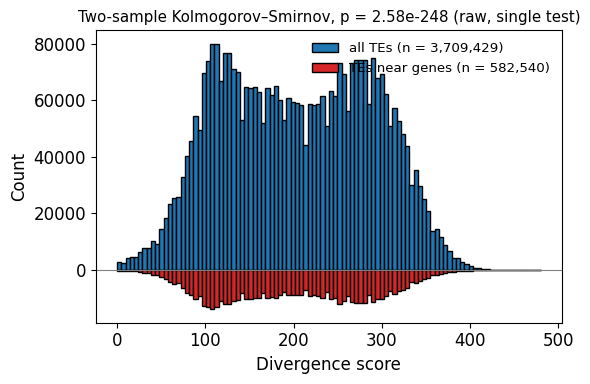

Fig3A: KS p = 2.578e-248 -> Fig3A_relabelled.svg


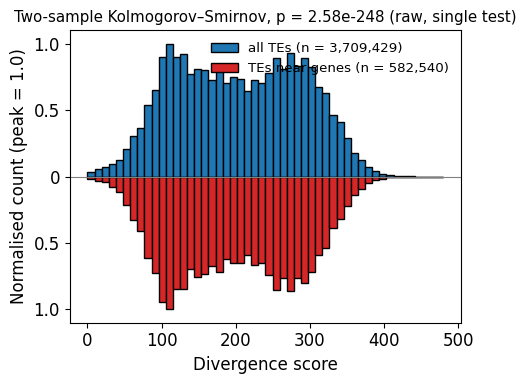

Fig3B: KS p = 2.578e-248 -> Fig3B_relabelled.svg


In [6]:
def divergence_ridge(column, normalise, bin_count, panel_name, x_label, figsize):
    """All TEs vs TEs near genes, as mirrored histograms with a labelled K-S test."""
    scores_all = repeat_masker[column].dropna()
    scores_genes = repeat_masker_genes[column].dropna()
    bin_range = (repeat_masker[column].min(), repeat_masker[column].max())

    ks_result = kstest(scores_all, scores_genes)
    p_value = ks_result.pvalue
    p_text = ("p < 1e-300" if p_value == 0 else
              f"p = {p_value:.2e}" if p_value < 0.001 else f"p = {p_value:.3f}")

    counts_all, bins = np.histogram(scores_all, bins=bin_count, range=bin_range)
    counts_genes, _ = np.histogram(scores_genes, bins=bin_count, range=bin_range)
    if normalise:
        counts_all = counts_all / max(counts_all.max(), 1)
        counts_genes = counts_genes / max(counts_genes.max(), 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(bin_centers, counts_all, width=bins[1] - bins[0], color="#1f77b4",
           edgecolor="black", label=f"all TEs (n = {len(scores_all):,})")
    ax.bar(bin_centers, -counts_genes, width=bins[1] - bins[0], color="#d62728",
           edgecolor="black", label=f"TEs near genes (n = {len(scores_genes):,})")
    ax.axhline(0, color="gray", linewidth=0.8)

    if normalise:
        ax.set_ylim(-1.1, 1.1)
        ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
        ax.set_yticklabels(["1.0", "0.5", "0", "0.5", "1.0"])
        ax.set_ylabel("Normalised count (peak = 1.0)", fontsize=rl.fs(10))
    else:
        ax.set_yticklabels([f"{abs(y):.0f}" for y in ax.get_yticks()])
        ax.set_ylabel("Count", fontsize=rl.fs(10))

    ax.set_xlabel(x_label, fontsize=rl.fs(10))
    # LABEL FIX: the test is named and declared raw.
    ax.set_title(f"Two-sample Kolmogorov–Smirnov, {p_text} (raw, single test)",
                 fontsize=rl.fs(9))
    ax.legend(loc="upper right", frameon=False, fontsize=rl.fs(8))
    fig.tight_layout()
    path = os.path.join(SVG, f"{panel_name}_relabelled.svg")
    fig.savefig(path, format="svg", transparent=True, bbox_inches="tight")
    plt.show()
    print(f"{panel_name}: KS p = {p_value:.3e} -> {os.path.basename(path)}")


divergence_ridge("score", normalise=False, bin_count=100, panel_name="Fig3A",
                 x_label="Divergence score", figsize=(6, 4))
divergence_ridge("score", normalise=True, bin_count=50, panel_name="Fig3B",
                 x_label="Divergence score", figsize=(5, 4))

## 6. Supplementary Figure S1 — the same comparison per TE class

Copied from frozen cell 172. Six panels, peak-normalised, one K-S test per class. These are
six independent tests, so the panel now says the p-values are raw and how many were run —
the frozen version reported neither.

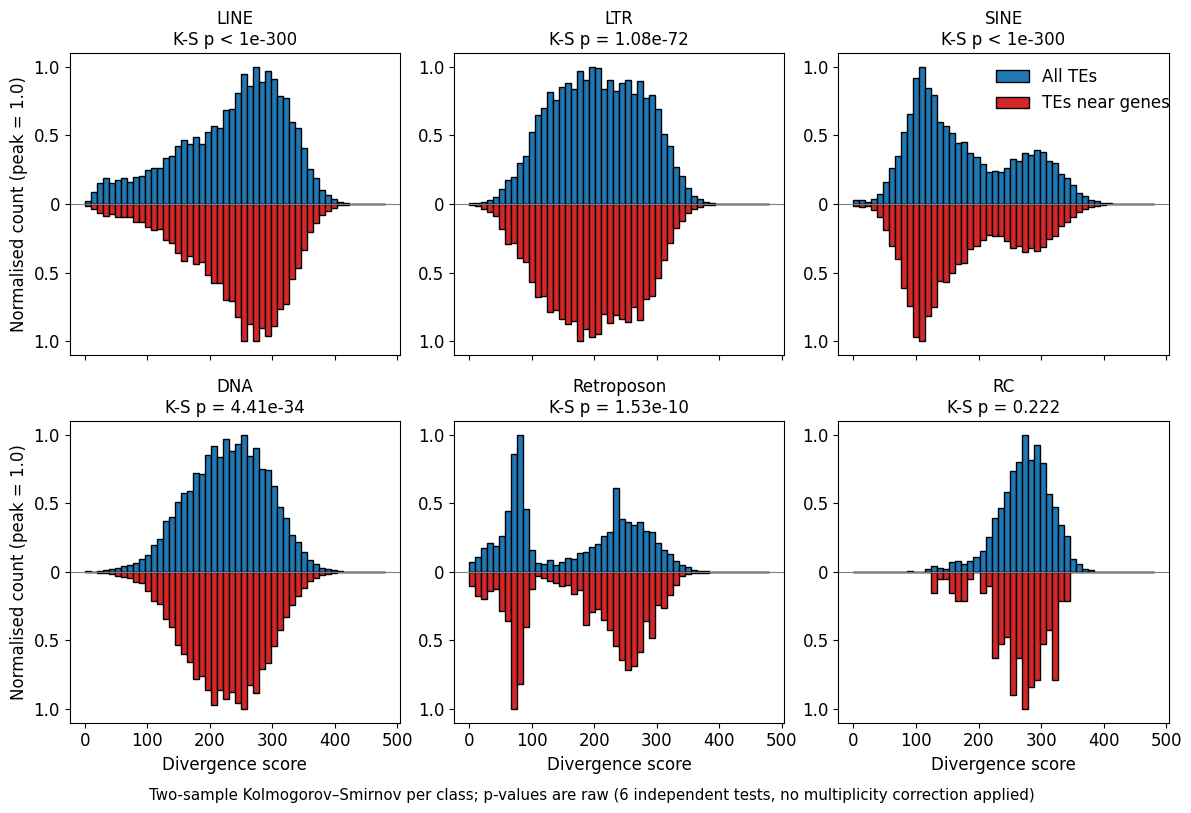

In [7]:
BIN_COUNT = 50
bin_range = (repeat_masker["score"].min(), repeat_masker["score"].max())
NROWS, NCOLS = 2, 3

figure, axs = plt.subplots(nrows=NROWS, ncols=NCOLS, sharex=True, sharey=False,
                           figsize=(12, 8))
for i, (class_name, ax) in enumerate(zip(class_names, axs.flatten())):
    r, c = i // NCOLS, i % NCOLS
    scores_all = repeat_masker.loc[repeat_masker.class_name == class_name,
                                   "score"].dropna()
    scores_genes = repeat_masker_genes.loc[repeat_masker_genes.class_name == class_name,
                                           "score"].dropna()
    p_value = kstest(scores_all, scores_genes).pvalue
    p_text = ("p < 1e-300" if p_value == 0 else
              f"p = {p_value:.2e}" if p_value < 0.001 else f"p = {p_value:.3f}")

    counts_all, bins = np.histogram(scores_all, bins=BIN_COUNT, range=bin_range)
    counts_genes, _ = np.histogram(scores_genes, bins=BIN_COUNT, range=bin_range)
    norm_all = counts_all / max(counts_all.max(), 1)
    norm_genes = counts_genes / max(counts_genes.max(), 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    ax.bar(bin_centers, norm_all, width=bins[1] - bins[0], color="#1f77b4",
           edgecolor="black", label="All TEs")
    ax.bar(bin_centers, -norm_genes, width=bins[1] - bins[0], color="#d62728",
           edgecolor="black", label="TEs near genes")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_ylim(-1.1, 1.1)
    ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
    ax.set_yticklabels(["1.0", "0.5", "0", "0.5", "1.0"])
    ax.set_title(f"{class_name}\nK-S {p_text}", fontsize=rl.fs(10))
    if r == NROWS - 1:
        ax.set_xlabel("Divergence score")
    ax.set_ylabel("Normalised count (peak = 1.0)" if c == 0 else "")

axs[0, NCOLS - 1].legend(loc="upper right", frameon=False, bbox_to_anchor=(1.05, 1.0))
# LABEL FIX: the provenance sentence replaces the removed suptitle (G11).
figure.text(0.5, -0.01,
            "Two-sample Kolmogorov–Smirnov per class; p-values are raw (6 independent tests, "
            "no multiplicity correction applied)",
            ha="center", fontsize=rl.fs(9))
figure.tight_layout()
figure.savefig(os.path.join(SVG, "S1_relabelled.svg"), format="svg", transparent=True,
               bbox_inches="tight")
plt.show()

## 7. Supplementary Figures S2 and S3 — per-family divergence and length

Copied from frozen cells 181 (divergence) and 194 (length). 44 panels, the 44 most abundant
families, peak-normalised, with significance stars from a Mann–Whitney U test per family
**Benjamini–Hochberg corrected across the 44 families**.

**The plan expected this to be "already stated"; verification shows it is not.** The frozen
figures render only a family name and bare stars — nothing on the artwork says the stars are
FDR-corrected or what test produced them. Both panels gain an explicit star legend.

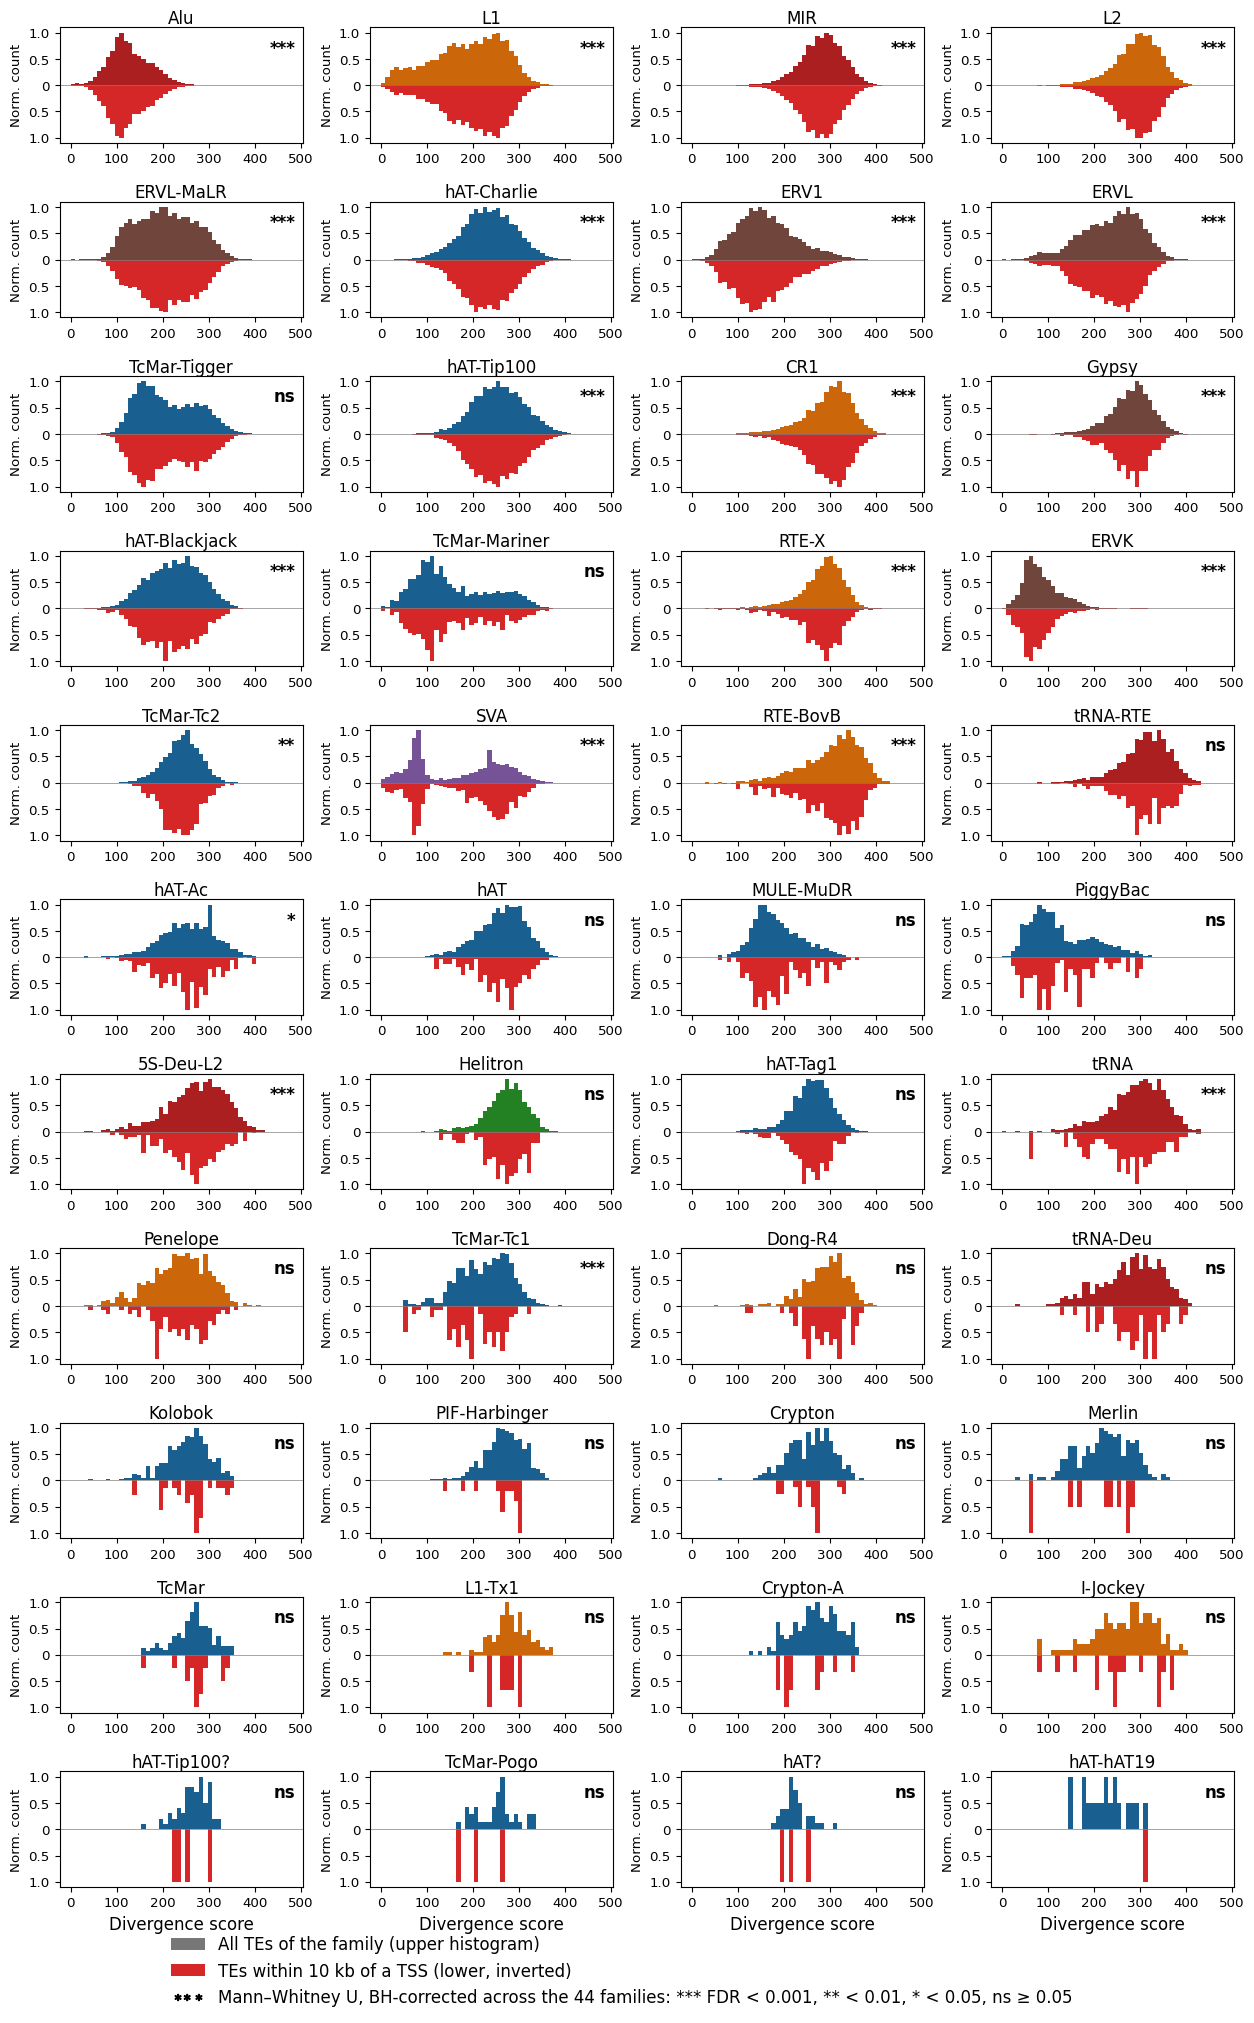

S2: 21 of 44 families significant at FDR < 0.05 -> S2_relabelled.svg


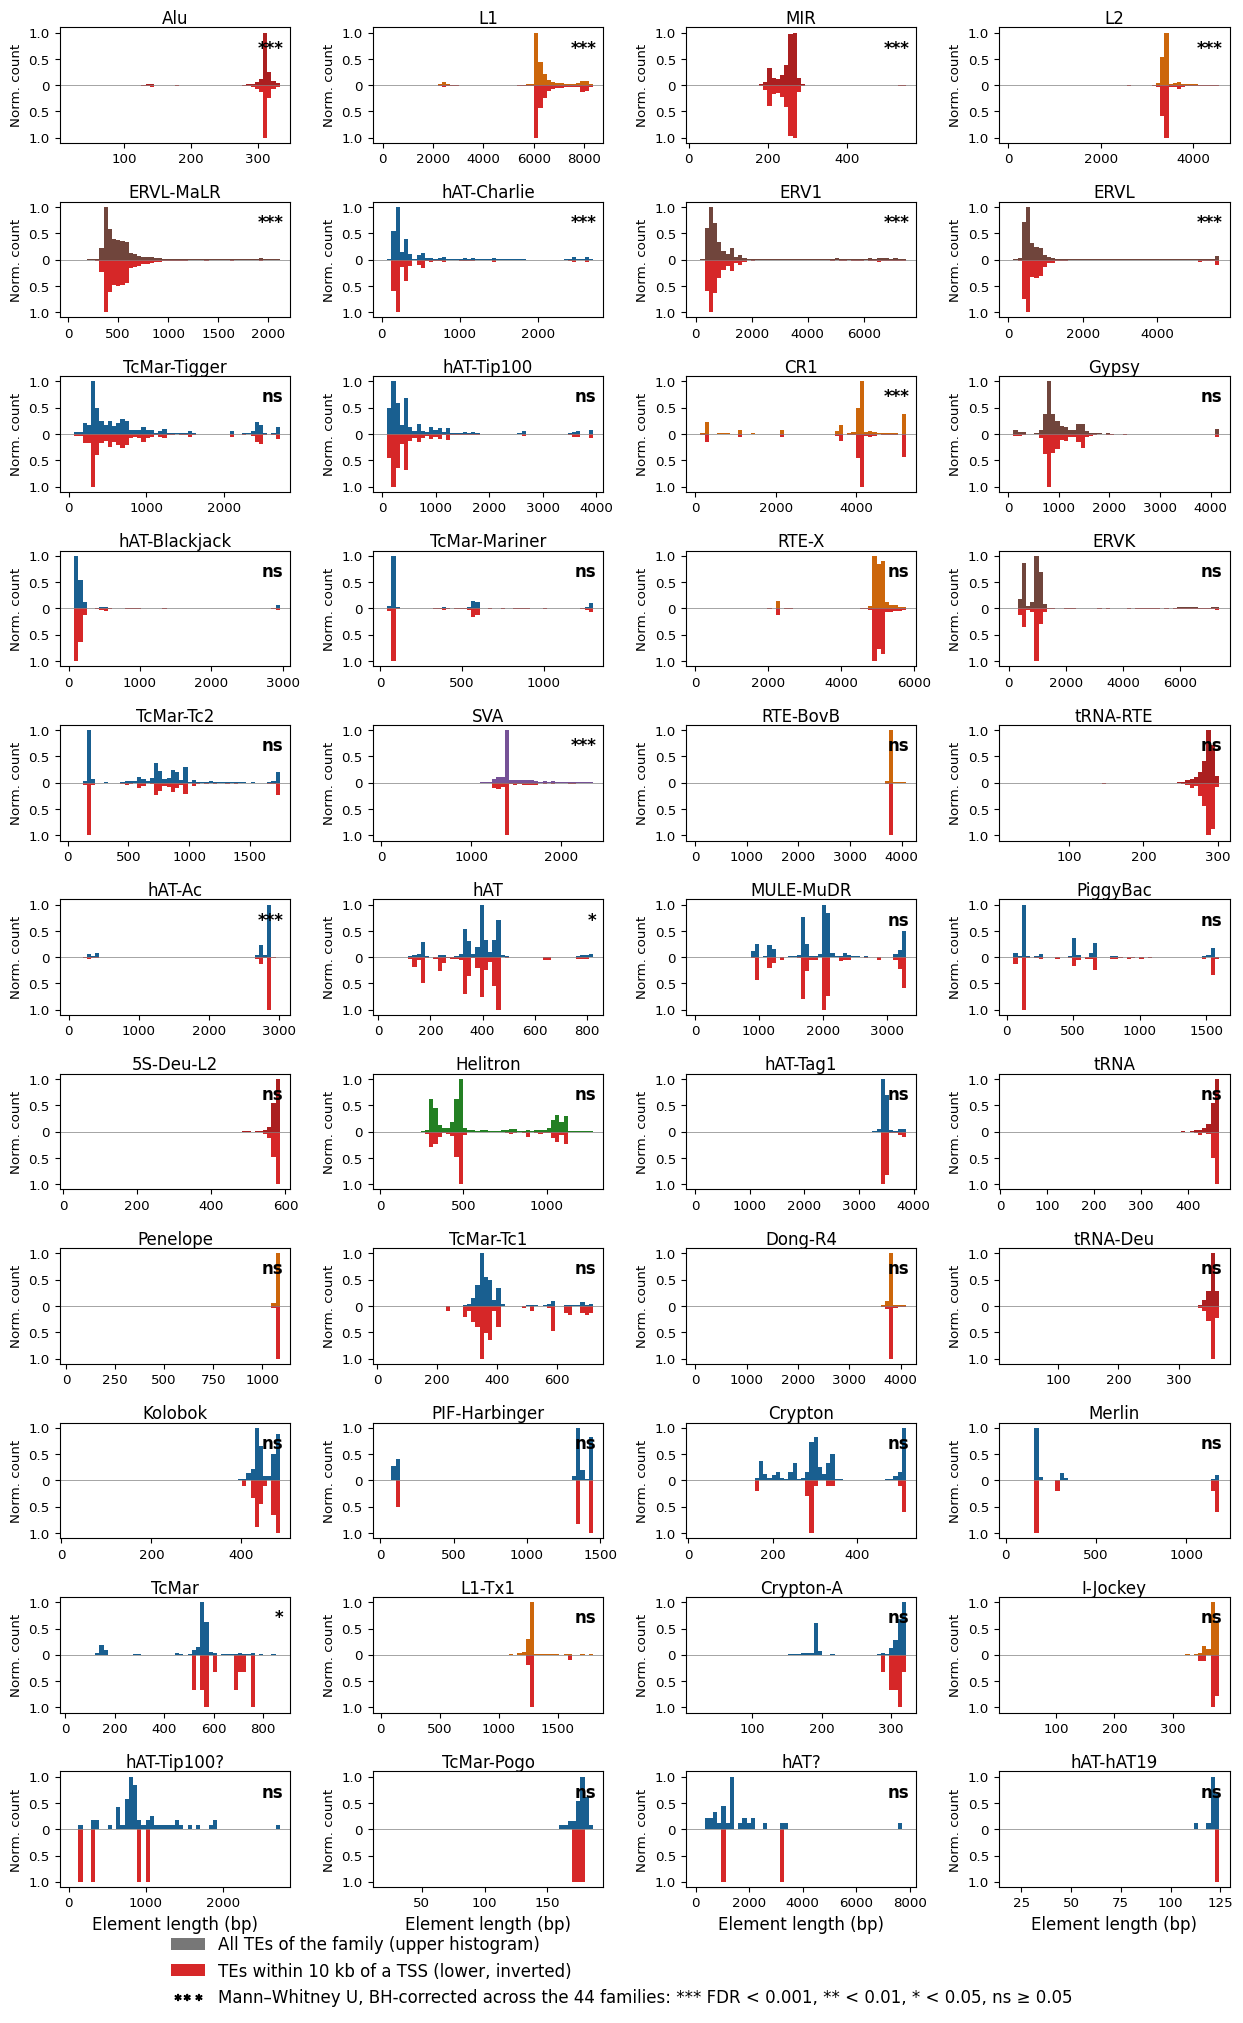

S3: 13 of 44 families significant at FDR < 0.05 -> S3_relabelled.svg


In [8]:
def per_family_ridge(column, panel_name, x_label, use_percentile_range):
    """44-panel family grid with BH-corrected Mann-Whitney stars and a stated legend."""
    NROWS, NCOLS = 11, 4
    BIN_COUNT = 50
    family_names = repeat_masker["family_name"].value_counts().index[: NROWS * NCOLS]

    raw_p_values, valid_families = [], []
    for family_name in family_names:
        all_values = repeat_masker.loc[repeat_masker.family_name == family_name,
                                       column].dropna()
        gene_values = repeat_masker_genes.loc[
            repeat_masker_genes.family_name == family_name, column].dropna()
        if len(all_values) > 1 and len(gene_values) > 1:
            raw_p_values.append(stats.mannwhitneyu(all_values, gene_values).pvalue)
            valid_families.append(family_name)

    _, adj_p_values, _, _ = multipletests(raw_p_values, method="fdr_bh")
    family_stats = dict(zip(valid_families, adj_p_values))

    def get_stars(p):
        if p < 0.001:
            return "***"
        if p < 0.01:
            return "**"
        if p < 0.05:
            return "*"
        return "ns"

    figure, axs = plt.subplots(nrows=NROWS, ncols=NCOLS, figsize=(12.6, 20))
    rows = []
    for i, (family_name, ax) in enumerate(zip(family_names, axs.flatten())):
        r = i // NCOLS
        all_values = repeat_masker.loc[repeat_masker.family_name == family_name,
                                       column].dropna()
        gene_values = repeat_masker_genes.loc[
            repeat_masker_genes.family_name == family_name, column].dropna()
        class_name = repeat_masker.loc[repeat_masker.family_name == family_name,
                                       "class_name"].iloc[0]

        # Length is heavy-tailed, so cell 194 clips the axis at the 95th percentile.
        upper = (np.percentile(all_values, 95) if use_percentile_range
                 else repeat_masker[column].max())
        bin_range = (repeat_masker[column].min(), upper)

        counts_all, bins = np.histogram(all_values, bins=BIN_COUNT, range=bin_range)
        counts_genes, _ = np.histogram(gene_values, bins=BIN_COUNT, range=bin_range)
        norm_all = counts_all / max(counts_all.max(), 1)
        norm_genes = counts_genes / max(counts_genes.max(), 1)
        bin_centers = (bins[:-1] + bins[1:]) / 2

        ax.bar(bin_centers, norm_all, width=bins[1] - bins[0],
               color=class_names_p.get(class_name, "#1f77b4"), edgecolor="none",
               label="All TEs")
        ax.bar(bin_centers, -norm_genes, width=bins[1] - bins[0], color="#d62728",
               edgecolor="none", label="TEs near genes")
        ax.axhline(0, color="gray", linewidth=0.5)

        p_adj = family_stats.get(family_name, 1.0)
        ax.text(0.97, 0.9, get_stars(p_adj), transform=ax.transAxes, ha="right",
                va="top", fontsize=rl.GLOBAL_FONT_SIZE, weight="bold")
        ax.set_title(family_name, fontsize=rl.GLOBAL_FONT_SIZE, pad=2)
        ax.set_ylim(-1.1, 1.1)
        ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
        ax.set_yticklabels(["1.0", "0.5", "0", "0.5", "1.0"],
                           fontsize=rl.fs(8))
        ax.tick_params(axis="x", labelsize=rl.fs(8))
        if r == NROWS - 1:
            ax.set_xlabel(x_label, fontsize=rl.GLOBAL_FONT_SIZE)
        ax.set_ylabel("Norm. count", fontsize=rl.fs(8))
        rows.append({"family_name": family_name, "p_adj_bh": p_adj,
                     "stars": get_stars(p_adj)})

    handles = [
        Patch(facecolor="#777777", label="All TEs of the family (upper histogram)"),
        Patch(facecolor="#d62728", label="TEs within 10 kb of a TSS (lower, inverted)"),
        Line2D([], [], ls="", marker="$***$", color="black", markersize=rl.fs(16),
               label="Mann–Whitney U, BH-corrected across the 44 families: "
                     "*** FDR < 0.001, ** < 0.01, * < 0.05, ns ≥ 0.05"),
    ]
    figure.legend(handles=handles, loc="lower center", ncol=1, frameon=False,
                  fontsize=rl.GLOBAL_FONT_SIZE, bbox_to_anchor=(0.5, -0.015))
    figure.tight_layout(rect=[0, 0.02, 1, 1])
    path = os.path.join(SVG, f"{panel_name}_relabelled.svg")
    figure.savefig(path, format="svg", transparent=True, bbox_inches="tight")
    plt.show()

    table = pd.DataFrame(rows)
    table.to_csv(os.path.join(OUT, f"{panel_name}_family_mannwhitney_fdr.csv"),
                 index=False)
    print(f"{panel_name}: {int((table.p_adj_bh < 0.05).sum())} of {len(table)} families "
          f"significant at FDR < 0.05 -> {os.path.basename(path)}")
    return table


s2_stats = per_family_ridge("score", "S2", "Divergence score", use_percentile_range=False)
s3_stats = per_family_ridge("length", "S3", "Element length (bp)",
                            use_percentile_range=True)

## 8. SVGs written, and the invariants that matter

Two checks. The first is that the values are the published ones: every panel above plots a
column of a CSV this revision does not touch, so if a number moved it would be a bug, not a
revision.

The second is new, and is the test for the Figure 2D–2F correction. The published Results
paragraph makes three specific statements about which class pairs differ significantly, one
per panel. At family level with the caption's letter order they must all three come out
exactly — and if a future edit puts the panels back at the wrong level or swaps the letters
again, this is what catches it.

In [9]:
check = enrichment_df_families.set_index("family_name")
print("Figure 1D spot check against the published table (must match exactly):")
for family_name in ["Alu", "L1", "SVA", "MIR", "hAT-Charlie"]:
    row = check.loc[family_name]
    print(f"  {family_name:12s} observed OR {row.Observed_Odds_Ratio:.4f}   "
          f"obs/random {row.OR_Observed_to_Random:.4f}   "
          f"FDR-corrected Fisher p {row.Enrichment_p_value_adjusted:.3g}")

# The published Results, Figure 2 paragraph, sentence by sentence:
#   2D obs/random OR  "DNA elements were significantly depleted ... compared to SINEs ...
#                      all the rest pairwise comparisons were non-significant"
#   2E observed OR    "significantly lower for DNA elements compared to both LINEs and SINEs"
#   2F random OR      "the highest number of significant differences was found by the random
#                      background OR: between DNA elements and LINEs, between LINEs and
#                      SINEs and between LTRs and SINEs"
EXPECTED_SIGNIFICANT = {
    "Fig2D": {("DNA", "SINE")},
    "Fig2E": {("DNA", "LINE"), ("DNA", "SINE")},
    "Fig2F": {("DNA", "LINE"), ("LINE", "SINE"), ("LTR", "SINE")},
}
print("\nFigure 2D-2F caption conformance:")
for panel, expected in EXPECTED_SIGNIFICANT.items():
    got = {tuple(sorted(pair)) for pair in significant_pairs[panel]}
    want = {tuple(sorted(pair)) for pair in expected}
    print(f"  {panel}: {sorted(got)}")
    assert got == want, (
        f"{panel} no longer reproduces the published sentence: {sorted(got)} "
        f"vs {sorted(want)}"
    )
print("Figures 2D-2F reproduce the three published significance statements")

print("\nSVGs written by this notebook:")
for name in sorted(os.listdir(SVG)):
    if name.endswith("_relabelled.svg"):
        path = os.path.join(SVG, name)
        print(f"  {name:34s} {os.path.getsize(path):>9,} B")

Figure 1D spot check against the published table (must match exactly):
  Alu          observed OR 2.3233   obs/random 1.5134   FDR-corrected Fisher p 0
  L1           observed OR 1.8230   obs/random 0.6844   FDR-corrected Fisher p 0
  SVA          observed OR 2.3957   obs/random 1.3684   FDR-corrected Fisher p 4.1e-132
  MIR          observed OR 2.1098   obs/random 1.3766   FDR-corrected Fisher p 0
  hAT-Charlie  observed OR 1.6453   obs/random 1.0411   FDR-corrected Fisher p 0

Figure 2D-2F caption conformance:
  Fig2D: [('DNA', 'SINE')]
  Fig2E: [('DNA', 'LINE'), ('DNA', 'SINE')]
  Fig2F: [('DNA', 'LINE'), ('LINE', 'SINE'), ('LTR', 'SINE')]
Figures 2D-2F reproduce the three published significance statements

SVGs written by this notebook:
  Fig1D_relabelled.svg                 241,047 B
  Fig2D_relabelled.svg                  51,341 B
  Fig2E_relabelled.svg                  51,195 B
  Fig2F_relabelled.svg                  53,420 B
  Fig3A_relabelled.svg                  59,085 B
  Fi